In [ ]:
%%writefile TSP_DIDP_model_and_dual_bounds_declaration.py
import sys
import os
import numpy as np
import modified_didppy as m_dp
from ortools.linear_solver import pywraplp
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.optimize import linear_sum_assignment
from numpy.linalg import eigh
from functools import lru_cache

# --- GLOBALS ---
current_num_locations = 0
current_travel_cost = []

# --- READER ---
def read_tsp_cappart_format(file_path):
    with open(file_path, 'r') as f:
        values = f.read().split()
    iterator = iter(values)
    try:
        n = int(next(iterator))
        c = []
        for i in range(n):
            row = []
            for j in range(n):
                row.append(int(float(next(iterator))))
            c.append(row)
        return n, c
    except StopIteration:
        return 0, []

# --- MODEL DEFINITION ---
def creation_of_didp_model_function():
    n = current_num_locations
    c = current_travel_cost
    
    model = m_dp.Model(maximize=False, float_cost=True)
    customer = model.add_object_type(number=n)
    unvisited = model.add_set_var(object_type=customer, target=list(range(1, n)))
    location = model.add_element_var(object_type=customer, target=0)
    travel_time = model.add_float_table(c)

    for j in range(1, n):
        visit = m_dp.Transition(
            name=f"visit {j}",
            cost=travel_time[location, j] + m_dp.FloatExpr.state_cost(),
            preconditions=[unvisited.contains(j)],
            effects=[(unvisited, unvisited.remove(j)), (location, j)],
        )
        model.add_transition(visit)

    return_to_depot = m_dp.Transition(
        name="return",
        cost=travel_time[location, 0] + m_dp.FloatExpr.state_cost(),
        effects=[(location, 0)],
        preconditions=[unvisited.is_empty(), location != 0],
    )
    model.add_transition(return_to_depot)
    model.add_base_case([unvisited.is_empty(), location == 0])
    
    metadata = {
        "num_nodes": n,
        "distance_matrix": c,
        "unvisited_var": unvisited,
        "location_var": location,
    }
    return model, metadata

# --- DUAL BOUNDS ---
def create_persistent_lp_relaxation_3_index_dual_bounds(metadata):
    n_nodes = metadata['num_nodes']
    dist_matrix = metadata['distance_matrix']
    unvisited_var = metadata['unvisited_var']
    location_var = metadata['location_var']

    solver = pywraplp.Solver.CreateSolver('GLOP')
    if not solver: return lambda state: 0.0
    infinity = solver.infinity()

    x = {}
    u = {}
    for i in range(n_nodes):
        u[i] = solver.NumVar(0, n_nodes, f'u_{i}')
        for j in range(n_nodes):
            if i != j: x[(i, j)] = solver.NumVar(0, 1, f'x_{i}_{j}')

    cons_out = {}
    cons_in = {}
    for i in range(n_nodes):
        c_out = solver.Constraint(0, 0, f'out_{i}')
        c_in = solver.Constraint(0, 0, f'in_{i}')
        for j in range(n_nodes):
            if i != j:
                c_out.SetCoefficient(x[(i, j)], 1)
                c_in.SetCoefficient(x[(j, i)], 1)
        cons_out[i] = c_out
        cons_in[i] = c_in

    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j:
                c = solver.Constraint(-infinity, n_nodes - 1, f'mtz_{i}_{j}')
                c.SetCoefficient(u[i], 1)
                c.SetCoefficient(u[j], -1)
                c.SetCoefficient(x[(i, j)], n_nodes)

    objective = solver.Objective()
    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j: objective.SetCoefficient(x[(i, j)], dist_matrix[i][j])
    objective.SetMinimization()

    @lru_cache(maxsize=10000)
    def _solve_3idx(active_tuple):
        current_node = active_tuple[0]
        active_set = set(active_tuple[1:])
        active_set.add(current_node)
        active_set.add(0) 
        max_u = len(active_set) 

        for i in range(n_nodes):
            if i in active_set:
                if i == current_node:
                    cons_out[i].SetBounds(1, 1); cons_in[i].SetBounds(0, 0); u[i].SetBounds(0, 0)
                elif i == 0:
                    cons_out[i].SetBounds(0, 0); cons_in[i].SetBounds(1, 1); u[i].SetBounds(1, max_u)
                else:
                    cons_out[i].SetBounds(1, 1); cons_in[i].SetBounds(1, 1); u[i].SetBounds(1, max_u)
            else:
                cons_out[i].SetBounds(0, 0); cons_in[i].SetBounds(0, 0); u[i].SetBounds(0, 0)

        solver.SetTimeLimit(100)
        status = solver.Solve()
        if status == pywraplp.Solver.OPTIMAL or status == pywraplp.Solver.FEASIBLE:
            return float(objective.Value())
        return 0.0

    def h_lp_relaxation_3_idx(state):
        unvisited = state[unvisited_var]
        curr = state[location_var]
        if not unvisited and curr == 0: return 0.0
        key = (curr,) + tuple(sorted(list(unvisited)))
        return _solve_3idx(key)

    return h_lp_relaxation_3_idx

def create_persistent_lp_relaxation_2_index_dual_bounds(metadata):
    n_nodes = metadata['num_nodes']
    dist_matrix = metadata['distance_matrix']
    unvisited_var = metadata['unvisited_var']
    location_var = metadata['location_var']

    solver = pywraplp.Solver.CreateSolver('GLOP')
    if not solver: return lambda state: 0.0

    x = {}
    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j: x[(i, j)] = solver.NumVar(0, 1, f'x_{i}_{j}')

    cons_out = {}
    cons_in = {}
    for i in range(n_nodes):
        c_out = solver.Constraint(0, 0, f'out_{i}')
        c_in = solver.Constraint(0, 0, f'in_{i}')
        for j in range(n_nodes):
            if i != j:
                c_out.SetCoefficient(x[(i, j)], 1)
                c_in.SetCoefficient(x[(j, i)], 1)
        cons_out[i] = c_out
        cons_in[i] = c_in

    objective = solver.Objective()
    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j: objective.SetCoefficient(x[(i, j)], dist_matrix[i][j])
    objective.SetMinimization()

    @lru_cache(maxsize=10000)
    def _solve_2idx(active_tuple):
        current_node = active_tuple[0]
        active_set = set(active_tuple[1:])
        active_set.add(current_node)
        active_set.add(0)

        for i in range(n_nodes):
            if i in active_set:
                if i == current_node:
                    cons_out[i].SetBounds(1, 1); cons_in[i].SetBounds(0, 0)
                elif i == 0:
                    cons_out[i].SetBounds(0, 0); cons_in[i].SetBounds(1, 1)
                else:
                    cons_out[i].SetBounds(1, 1); cons_in[i].SetBounds(1, 1)
            else:
                cons_out[i].SetBounds(0, 0); cons_in[i].SetBounds(0, 0)

        solver.SetTimeLimit(100)
        status = solver.Solve()
        if status == pywraplp.Solver.OPTIMAL or status == pywraplp.Solver.FEASIBLE:
            return float(objective.Value())
        return 0.0

    def h_lp_relaxation_2_idx(state):
        unvisited = state[unvisited_var]
        curr = state[location_var]
        if not unvisited and curr == 0: return 0.0
        key = (curr,) + tuple(sorted(list(unvisited)))
        return _solve_2idx(key)

    return h_lp_relaxation_2_idx

def dual_bound_expression_function(didp_bundle):
    model, metadata = didp_bundle
    unvisited_var = metadata['unvisited_var']
    location_var = metadata['location_var']
    cost_matrix = np.array(metadata['distance_matrix'])
    
    masked_cost = cost_matrix.astype(float).copy()
    np.fill_diagonal(masked_cost, np.inf)
    min_outgoing_arr = np.min(masked_cost, axis=1)
    min_incoming_arr = np.min(masked_cost, axis=0)

    h_lp_relaxation_3_idx = create_persistent_lp_relaxation_3_index_dual_bounds(metadata)
    h_lp_relaxation_2_idx = create_persistent_lp_relaxation_2_index_dual_bounds(metadata)

    @lru_cache(maxsize=100000)
    def _calc_degree(active_tuple):
        nodes = list(active_tuple)
        sub_mat = cost_matrix[np.ix_(nodes, nodes)].astype(float)
        np.fill_diagonal(sub_mat, np.inf)
        mins_in = np.min(sub_mat, axis=0) 
        mins_out = np.min(sub_mat, axis=1)
        sum_in = np.sum(mins_in[1:])
        sum_out = np.sum(mins_out[:-1])
        return float(0.5 * (sum_in + sum_out))

    def h_degree_average(state):
        U = state[unvisited_var]
        curr = state[location_var]
        if not U and curr == 0: return 0.0
        active_list = [curr] + sorted(list(U))
        if 0 not in active_list: active_list.append(0)
        return _calc_degree(tuple(active_list))

    @lru_cache(maxsize=100000)
    def _calc_min_flow_static(unvisited_tuple):
        val_out = sum(min_outgoing_arr[u] for u in unvisited_tuple)
        val_in = sum(min_incoming_arr[u] for u in unvisited_tuple)
        return val_out, val_in

    def h_global_min_flow(state):
        U = state[unvisited_var]
        curr = state[location_var]
        if not U and curr == 0: return 0.0
        val_out, val_in = _calc_min_flow_static(tuple(sorted(list(U))))
        if curr != 0:
            val_out += min_outgoing_arr[curr]
            val_in += min_incoming_arr[0]
        return float(max(val_out, val_in))

    @lru_cache(maxsize=100000)
    def _calc_mst(unvisited_tuple):
        if not unvisited_tuple: return 0.0
        nodes = [0] + list(unvisited_tuple)
        sub_mat = cost_matrix[np.ix_(nodes, nodes)]
        mst = minimum_spanning_tree(sub_mat)
        return float(mst.sum())

    def h_mst(state):
        U = state[unvisited_var]
        return _calc_mst(tuple(sorted(list(U))))

    @lru_cache(maxsize=100000)
    def _calc_1tree(unvisited_tuple):
        subset = list(unvisited_tuple)
        depot_edges = sorted(cost_matrix[0, subset])
        e1 = depot_edges[0]
        e2 = depot_edges[1] if len(depot_edges) > 1 else 0.0
        if len(subset) > 1:
            sub_mat = cost_matrix[np.ix_(subset, subset)]
            mst_val = minimum_spanning_tree(sub_mat).sum()
        else:
            mst_val = 0.0
        return float(mst_val + e1 + e2)

    def h_1tree(state):
        U = state[unvisited_var]
        if not U: return 0.0
        return _calc_1tree(tuple(sorted(list(U))))

    @lru_cache(maxsize=100000)
    def _calc_assignment(unvisited_tuple):
        nodes = [0] + list(unvisited_tuple)
        sub_mat = cost_matrix[np.ix_(nodes, nodes)]
        assign_mat = sub_mat.astype(float).copy()
        np.fill_diagonal(assign_mat, np.inf)
        row, col = linear_sum_assignment(assign_mat)
        return float(assign_mat[row, col].sum())

    def h_assignment(state):
        U = state[unvisited_var]
        if not U: return 0.0
        return _calc_assignment(tuple(sorted(list(U))))

    @lru_cache(maxsize=100000)
    def _calc_eigen(unvisited_tuple):
        nodes = [0] + list(unvisited_tuple)
        N = len(nodes)
        if N < 2: return 0.0
        
        D_sub = cost_matrix[np.ix_(nodes, nodes)]
        one = np.ones((N, 1))
        P = np.eye(N) - (one @ one.T) / N
        M = -P @ D_sub @ P
        M = (M + M.T) / 2
        try:
            eigvals = np.flip(eigh(M)[0])
        except np.linalg.LinAlgError:
            return 0.0
        
        eigvals = eigvals[np.abs(eigvals) > 1e-9]
        coeffs = np.array([1 - np.cos(2 * np.pi * k / N) for k in range(1, N)])
        phi = 0.0
        if N > 1:
            if N % 2 == 1:
                num_terms = (N - 1) // 2
                if 2 * num_terms <= len(eigvals) and num_terms <= len(coeffs):
                     phi = sum(coeffs[k-1] * (eigvals[2*k - 2] + eigvals[2*k - 1]) for k in range(1, num_terms + 1))
            else:
                num_sum_terms = N // 2 - 1
                if 2 * num_sum_terms < len(eigvals) and num_sum_terms <= len(coeffs):
                    phi = sum(coeffs[k-1] * (eigvals[2*k - 2] + eigvals[2*k - 1]) for k in range(1, num_sum_terms + 1))
                    if N-2 < len(eigvals): phi += 2 * eigvals[N - 2]
                elif N > 1 and N-2 < len(eigvals):
                    phi = 2 * eigvals[N - 2]
        return float(phi)

    def h_eigen(state):
        U = state[unvisited_var]
        if not U: return 0.0
        return _calc_eigen(tuple(sorted(list(U))))

    from evolutionary_algorithm_lib.utils import automatic_creation_of_dual_bounds_registry
    return automatic_creation_of_dual_bounds_registry(locals())

Overwriting tsp_domain.py


In [ ]:
%%writefile worker_profiling.py
import sys
import os
import ast
import json
import time
import threading

# --- CONFIGURATION ---
MEMORY_LIMIT_MB = 4000  # Adjust as needed

# --- 1. SETUP PATHS ---
PROJECT_ROOT = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP"
LIB_PATH = os.path.join(PROJECT_ROOT, "Evolutionary_algorithm")

sys.path.append(os.getcwd()) # For TSP_DIDP_model_and_dual_bounds_declaration.py
if PROJECT_ROOT not in sys.path: sys.path.append(PROJECT_ROOT)
if LIB_PATH not in sys.path: sys.path.append(LIB_PATH)

# --- 2. IMPORTS ---
try:
    import psutil
    import modified_didppy as m_dp
    import TSP_DIDP_model_and_dual_bounds_declaration
    from evolutionary_algorithm_lib import compile_chromosome_to_useable_function
except ImportError as e:
    print(json.dumps({"status": "error", "message": f"Import Error: {e}"}))
    sys.exit(1)

# --- 3. MEMORY GUARD ---
def memory_guard():
    process = psutil.Process(os.getpid())
    limit_bytes = MEMORY_LIMIT_MB * 1024 * 1024
    while True:
        try:
            if process.memory_info().rss > limit_bytes:
                sys.stderr.write(f"\n[Guard] Memory limit ({MEMORY_LIMIT_MB}MB) reached.\n")
                sys.stderr.flush()
                os._exit(1)
            time.sleep(1)
        except: break

# --- 4. MAIN PROFILING LOGIC ---
if __name__ == "__main__":
    try:
        threading.Thread(target=memory_guard, daemon=True).start()

        if len(sys.argv) < 5: raise ValueError("Args: <instance> <chrom> <dir> <limit> <node_limit>")
        
        instance_name = sys.argv[1]
        chromosome_str = sys.argv[2]
        data_dir = sys.argv[3]
        time_limit = float(sys.argv[4])
        node_limit = int(sys.argv[5])

        # Load Data
        file_path = os.path.join(data_dir, instance_name)
        n_val, c_val = TSP_DIDP_model_and_dual_bounds_declaration.read_tsp_cappart_format(file_path)
        TSP_DIDP_model_and_dual_bounds_declaration.current_num_locations = n_val
        TSP_DIDP_model_and_dual_bounds_declaration.current_travel_cost = c_val

        # Setup Model
        model, metadata = TSP_DIDP_model_and_dual_bounds_declaration.creation_of_didp_model_function()
        
        # Setup Dual Bound from Chromosome
        chromosome = ast.literal_eval(chromosome_str)
        dual_bound_funcs = TSP_DIDP_model_and_dual_bounds_declaration.dual_bound_expression_function((model, metadata))
        h_func = compile_chromosome_to_useable_function(
            {'chromosome': chromosome, 'fitness': 0},
            dual_bound_functions_dict=dual_bound_funcs,
            print_code=False
        )

        # Create Custom Solver (Manually wrapped to access search_next)
        # Using CustomDualBoundCabsPy directly if possible or creating it via m_dp
        # We need to construct the solver such that we can run search_next
        solver = m_dp.CustomDualBoundCABSv1(
            model=model,
            dual_bound_func=h_func,
            time_limit=time_limit,
            quiet=True, # We want to control output
            print_timing_stats=False
        )

        # --- PROFILING LOOP ---
        history = [] # List of (expanded_nodes, cost)
        start_time = time.time()
        
        while True:
            # Check Limits
            if time.time() - start_time > time_limit: break
            
            # Run Next Step
            solution, is_terminated = solver.search_next()
            
            # Record Progress
            if solution.cost is not None:
                history.append((solution.expanded, solution.cost))
            
            # Termination Check
            if is_terminated:
                break
                
            # Stop if we exceeded node limit (soft check)
            if solution.expanded >= node_limit:
                break

        # Output Result
        output = {
            "status": "success",
            "history": history,
            "duration": time.time() - start_time
        }
        print(json.dumps(output))

    except Exception as e:
        # Fallback error reporting
        print(json.dumps({"status": "error", "message": str(e)}))
        sys.exit(1)

Overwriting worker_profiling.py


In [8]:
import subprocess
import pandas as pd
import numpy as np
import os
import sys
import json
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION
# ==========================================
NODE_EXPANSION_LIMIT = 1_000_000
SOLVER_TIME_LIMIT = 20
n_50_signal = True # Set True for 50 customers

if n_50_signal:
    DATA_DIR = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\1_TSP_dual_bounds_and_models\Datasets\n50"
    EA_RESULTS_CSV = "result_of_ea_TSP_dual_bounds_50_cus.csv"
    REF_RESULTS_CSV = "TSP_single_dual_bound_50_cus_results.csv"
    OUTPUT_FOLDER = "profiling_results_n50"
else:
    DATA_DIR = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\1_TSP_dual_bounds_and_models\Datasets\n20"
    EA_RESULTS_CSV = "result_of_ea_TSP_dual_bounds_20_cus.csv"
    REF_RESULTS_CSV = "TSP_single_dual_bound_20_cus_results.csv"
    OUTPUT_FOLDER = "profiling_results_n20"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# ==========================================
# HELPER: DENSE GAP CALCULATION
# ==========================================
def calculate_dense_gaps(history, optimal_cost, limit):
    """
    Converts sparse history [(100, 500), (5000, 450)] into a dense array 
    of gaps for every 1000th node count (to save space) or every node.
    Here we sample every 1000 nodes to keep file sizes manageable.
    """
    history.sort(key=lambda x: x[0])
    
    sample_rate = 100  # Record data point every 100 nodes
    max_steps = limit // sample_rate
    
    dense_gaps = np.full(max_steps, np.nan)
    
    current_cost = float('inf')
    hist_idx = 0
    
    for i in range(max_steps):
        current_node_count = (i + 1) * sample_rate
        
        # Update current best cost if we passed a history point
        while hist_idx < len(history) and history[hist_idx][0] <= current_node_count:
            if history[hist_idx][1] < current_cost:
                current_cost = history[hist_idx][1]
            hist_idx += 1
            
        # Calculate Gap
        if current_cost == float('inf'):
            gap = 100.0 # Arbitrary high gap for no solution
        else:
            gap = (current_cost - optimal_cost) / optimal_cost * 100.0
            if gap < 0: gap = 0.0 # Should not happen unless optimal is wrong
            
        dense_gaps[i] = gap
        
    return dense_gaps, sample_rate

# ==========================================
# MAIN EXECUTION
# ==========================================
def run_profiling_experiment():
    print(f"🔹 Starting Profiling (Max Nodes: {NODE_EXPANSION_LIMIT})...")
    
    # 1. Load Data
    if not os.path.exists(EA_RESULTS_CSV):
        print(f"❌ EA Results CSV missing: {EA_RESULTS_CSV}")
        return
    if not os.path.exists(REF_RESULTS_CSV):
        print(f"❌ Reference CSV missing: {REF_RESULTS_CSV}")
        return
        
    df_ea = pd.read_csv(EA_RESULTS_CSV)
    df_ref = pd.read_csv(REF_RESULTS_CSV)
    
    # Merge Reference Cost into EA DataFrame
    # Assuming 'Instance' column matches. 
    # Reference CSV might need cleaning (e.g. 98.txt vs 98)
    # We proceed assuming strict string match for now.
    df_merged = pd.merge(df_ea, df_ref[['Instance', 'Cost']], on='Instance', how='inner', suffixes=('', '_Ref'))
    
    # Store all dense gaps for averaging
    all_dense_gaps = [] 
    
    # 2. Loop Instances
    for i, row in df_merged.iterrows():
        instance = row['Instance']
        chrom = row['Best_Chromosome']
        optimal_cost = row['Cost']
        
        print(f"\n[{i+1}/{len(df_merged)}] Profiling {instance} (Opt: {optimal_cost})...")
        
        # Run Worker
        cmd = [
            sys.executable, "-u", "worker_profiling.py",
            instance, chrom, DATA_DIR, str(SOLVER_TIME_LIMIT), str(NODE_EXPANSION_LIMIT)
        ]
        
        try:
            result = subprocess.run(cmd, capture_output=True, text=True)
            
            if result.returncode != 0:
                print(f"   ⚠️ Worker Failed (Code {result.returncode})")
                # print(result.stderr) # Uncomment to debug
                continue
                
            # Parse Output
            # Look for JSON in stdout
            json_str = ""
            for line in result.stdout.split('\n'):
                if line.strip().startswith('{'):
                    json_str = line
            
            if not json_str:
                print("   ⚠️ No JSON output found.")
                continue
                
            data = json.loads(json_str)
            if data['status'] != 'success':
                print(f"   ⚠️ Worker Error: {data.get('message')}")
                continue
                
            history = data['history']
            print(f"   -> Retrieved {len(history)} history points.")
            
            # Process & Save Individual Data
            dense_gaps, step_size = calculate_dense_gaps(history, optimal_cost, NODE_EXPANSION_LIMIT)
            all_dense_gaps.append(dense_gaps)
            
            # Save to CSV
            df_hist = pd.DataFrame({
                'Node_Count': np.arange(step_size, NODE_EXPANSION_LIMIT + 1, step_size),
                'Gap_Percent': dense_gaps
            })
            safe_name = instance.replace(".txt", "")
            df_hist.to_csv(os.path.join(OUTPUT_FOLDER, f"gap_profile_{safe_name}.csv"), index=False)
            
        except Exception as e:
            print(f"   ❌ Execution Error: {e}")

    # 3. Aggregation & Plotting
    if all_dense_gaps:
        print("\n📊 Aggregating Results...")
        # Stack all arrays: Shape (Num_Instances, Num_Steps)
        gap_matrix = np.vstack(all_dense_gaps)
        
        # Calculate Mean
        mean_gaps = np.nanmean(gap_matrix, axis=0)
        
        # Save Aggregate
        step_size = 100
        x_axis = np.arange(step_size, NODE_EXPANSION_LIMIT + 1, step_size)
        df_agg = pd.DataFrame({
            'Node_Count': x_axis,
            'Average_Gap_Percent': mean_gaps
        })
        agg_path = os.path.join(OUTPUT_FOLDER, "AVERAGE_GAP_PROFILE.csv")
        df_agg.to_csv(agg_path, index=False)
        print(f"   ✅ Saved aggregated data to {agg_path}")
        
        # Plot
        plt.figure(figsize=(10, 6))
        plt.plot(x_axis, mean_gaps, label='Average Gap (%)', color='blue')
        plt.xlabel('Nodes Expanded')
        plt.ylabel('Optimality Gap (%)')
        plt.title(f'Convergence Profile (N={"50" if n_50_signal else "20"})')
        plt.grid(True)
        plt.legend()
        plot_path = os.path.join(OUTPUT_FOLDER, "convergence_plot.png")
        plt.savefig(plot_path)
        print(f"   ✅ Saved plot to {plot_path}")
        
    else:
        print("\n⚠️ No data collected to aggregate.")

🔹 Starting Profiling (Max Nodes: 1000000)...

[1/20] Profiling 61.txt (Opt: 665.0)...
   -> Retrieved 5 history points.

[2/20] Profiling 53.txt (Opt: 653.0)...
   -> Retrieved 6 history points.

[3/20] Profiling 50.txt (Opt: 671.0)...
   -> Retrieved 5 history points.

[4/20] Profiling 89.txt (Opt: 618.0)...
   -> Retrieved 5 history points.

[5/20] Profiling 31.txt (Opt: 570.0)...
   -> Retrieved 4 history points.

[6/20] Profiling 75.txt (Opt: 612.0)...
   -> Retrieved 5 history points.

[7/20] Profiling 52.txt (Opt: 643.0)...
   -> Retrieved 5 history points.

[8/20] Profiling 33.txt (Opt: 679.0)...
   -> Retrieved 5 history points.

[9/20] Profiling 39.txt (Opt: 630.0)...
   -> Retrieved 5 history points.

[10/20] Profiling 11.txt (Opt: 662.0)...
   -> Retrieved 6 history points.

[11/20] Profiling 14.txt (Opt: 661.0)...
   -> Retrieved 5 history points.

[12/20] Profiling 54.txt (Opt: 578.0)...
   -> Retrieved 6 history points.

[13/20] Profiling 78.txt (Opt: 654.0)...
   -> Retr

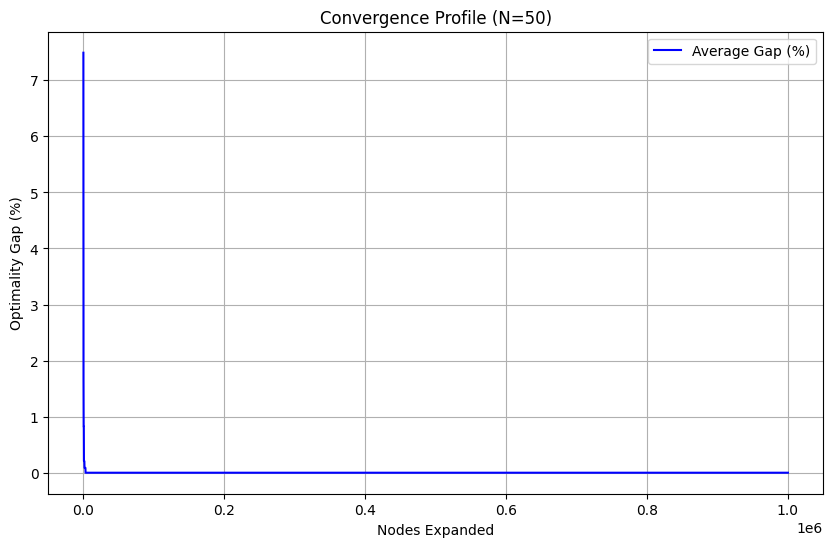

In [9]:
if __name__ == "__main__":
    run_profiling_experiment()